‎ 

> Source : [K Nearest Neighbors - Intuitive Machine Learning](https://www.youtube.com/watch?v=0p0o5cmgLdE)

‎ 


# 0. Setup

In [3]:
from Requirements import *

In [4]:
from tensorflow.keras.datasets import mnist

2025-09-29 09:57:34.187530: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-29 09:57:34.331596: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-29 09:57:34.482322: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-29 09:57:34.595984: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-29 09:57:34.628326: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-29 09:57:34.861384: I tensorflow/core/platform/cpu_feature_gu

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [6]:
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

print("\nData type of images:", x_train.dtype)
print("Data type of labels:", y_train.dtype)

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)

Data type of images: uint8
Data type of labels: uint8


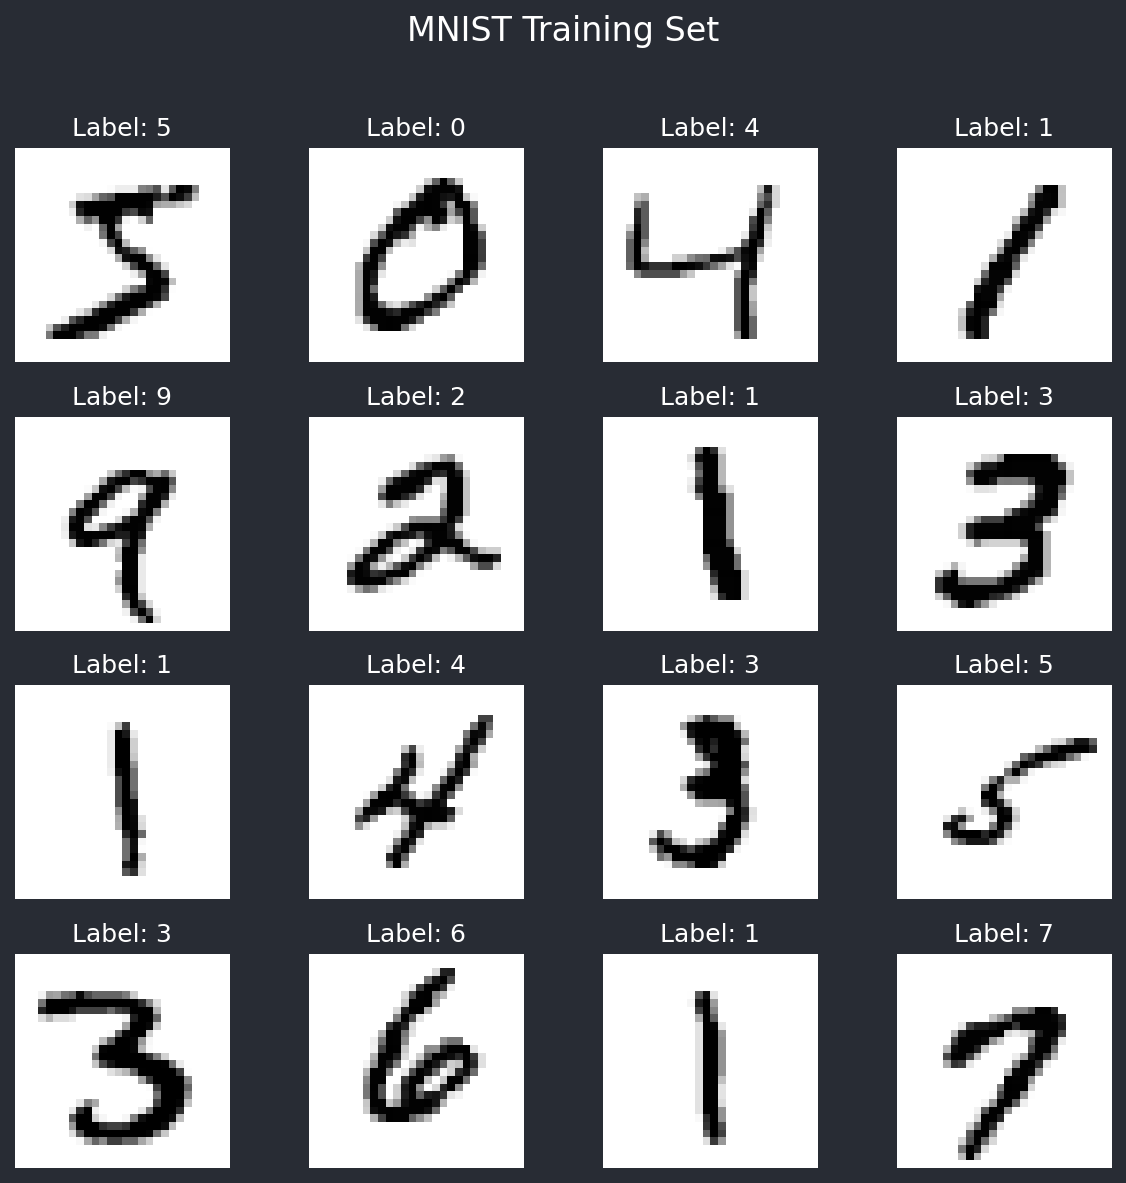

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(x_train[i], cmap='gray_r')
    
    ax.set_title(f"Label: {y_train[i]}")
    
    ax.axis('off')

plt.suptitle("MNIST Training Set", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

‎ 


# 1. Feature Vector Extraction 

The purpose of this section is to compare two different methods of extracting feature vectors from a test subject. For this project the MNIST dataset will be used, and the methods to be compared are: 

1. PCA - Principal Component Analysis

2. Texture and Statistic measurement

‎ 

## 1.1 PCA - Principal Component Analysis

PCA is a process to reduce the dimensionality of a dataset, while retaining as much variance as possible. It does this by identifying the directions (principal components) in which the data varies the most, and projecting the data onto these directions.

Let's assume we have a dataset represented by a matrix $X$ of size $n$ x $d$, where $n$ is the number of samples and $d$ is the number of features

‎ 

> 1. Standardize the Data

The first step in PCA is to standardize the data, which involves centering the data around the mean and scaling it to have unit variance. This is done so that each feature has a zero mean and unit variance. This prevents features with larger scales from dominating the analysis. For each feature column $j$ in $X$

$$
X_j' = \frac{X_j - \mu_j}{\sigma_j}
$$

where $X_j'$ is the standardized feature, $\mu_j$ is the mean of feature $j$, and $\sigma_j$ is the standard deviation of feature $j$. Let's call this new standardized data matrix $Z$.

‎ 

> 2. Compute the Covariance Matrix

The next step is to compute the covariance matrix of the standardized data. The covariance matrix captures the relationships between different features in the dataset. The covariance matrix $Σ$ is calculated as follows:

$$
\Sigma = \frac{1}{n-1} Z^T Z
$$

The terms $Z^T$ and $Z$ represent the transpose of the standardized data matrix and the standardized data matrix itself, respectively. The resulting covariance matrix $Σ$ will be of size $d$ x $d$, where each element $Σ_{ij}$ represents the covariance between features $i$ and $j$. The diagonal elements $Σ_{ii}$ represent the variance of each feature.

‎

> 3. Eigendecomposition of the Covariance Matrix

The next step is to perform eigendecomposition on the covariance matrix to find its eigenvalues and eigenvectors. The eigenvalues represent the amount of variance explained by each principal component, while the eigenvectors represent the directions of the principal components. This can be done using a linear algebra library or function that computes the eigenvalues and eigenvectors of a matrix.

$$
\Sigma v = \lambda v
$$

$v$ is an eigenvector of the covariance matrix $Σ$,  It's a $d$-dimensional vector. Eigenvectors represent the directions of the new axes in our feature space. Because the covariance matrix is symmetric, these eigenvectors will be orthogonal. These are the **principal components**.

$\lambda$ is the corresponding eigenvalue, which is a scalar. Eigenvalues indicate the amount of variance captured by each principal component. A higher eigenvalue means that the corresponding eigenvector captures more variance in the data.

‎

> 4. Sort Eigenvalues and Eigenvectors

We will get $d$ eigenvectors and $d$ corresponding eigenvalues. We sort the eigenvectors in descending order according to their eigenvalues.

The eigenvector with the largest eigenvalue is the first principal component (PC1). It is the direction that captures the most variance in the data. The eigenvector with the second-largest eigenvalue is the second principal component (PC2), which is orthogonal to PC1 and captures the most remaining variance, and so on. 


‎

> 5. Select Top $k$ Principal Components

To reduce the dimensionality of the dataset, we select the top $k$ eigenvectors (principal components) corresponding to the $k$ largest eigenvalues. The choice of $k$ depends on how much variance we want to retain in the reduced dataset. For this, we use the explained variance ratio, which is the ratio of each eigenvalue to the sum of all eigenvalues. 

$$
\text{Explained Variance Ratio} = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}
$$

We choose $k$ such that the explained variance ratio is above a certain threshold (e.g., 95%).

‎

> 6. Transform the Data

Finally, we project the standardized data $Z$, onto the selected $k$ principal components to obtain the reduced dataset. We create a matrix $W$ of size $d$ x $k$, where each column is one of the selected eigenvectors. 

$$
W = [v_1, v_2, ..., v_k]
$$

The new transformed dataset $Y$ is obtained by multiplying the standardized data matrix $Z$ with the projection matrix $W$:

$$
Y = Z W
$$

The resulting matrix $Y$ will be of size $n$ x $k$, where each row represents a sample in the reduced $k$-dimensional space. This reduced dataset can now be used for further analysis or machine learning tasks.

‎

____



‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

Before applying PCA, we need to prepare the data. For this, we need to flatten the images from 28x28 to 784-dimensional vectors and standardize the data.

</div>

‎ 

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [9]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)

x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("Shape of flattened x_train:", x_train_flat.shape)
print("Shape of flattened x_test:", x_test_flat.shape)


Shape of flattened x_train: (60000, 784)
Shape of flattened x_test: (10000, 784)


In [10]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_flat.astype(np.float64))
x_test_scaled = scaler.transform(x_test_flat.astype(np.float64))

# funding mean and std to verify standardization

print("Mean of scaled x_train :", np.mean(x_train_scaled, axis=0)[:].mean())
print("Std of scaled x_train :", np.std(x_train_scaled, axis=0)[:].mean())


Mean of scaled x_train : -4.908441927692891e-17
Std of scaled x_train : 0.9145408163265177


In [11]:
pca = PCA(n_components=0.95)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Shape of PCA-transformed x_train:", x_train_pca.shape)
print("Shape of PCA-transformed x_test:", x_test_pca.shape)

Shape of PCA-transformed x_train: (60000, 331)
Shape of PCA-transformed x_test: (10000, 331)



‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

To capture 95% of the information (variance) contained in the original 784 pixels, we only need 331 principal components. We've reduced the dimensionality of our data by over 50% while ensuring minimal information loss.

</div>

‎ 

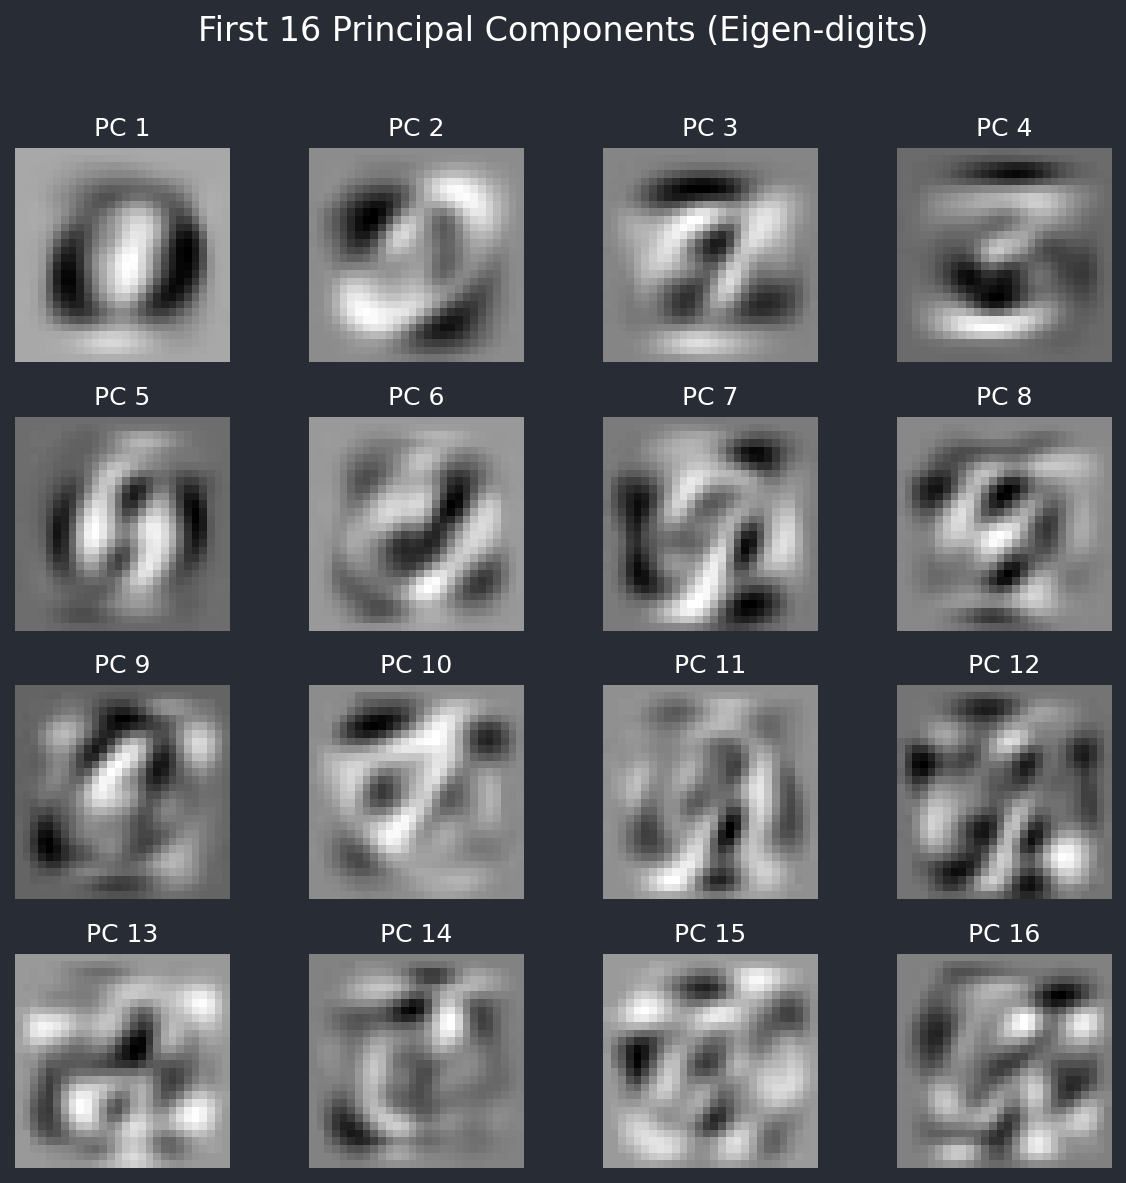

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(pca.components_[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')
    
plt.suptitle("First 16 Principal Components (Eigen-digits)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

Now we will implement the KNN algorithm using the PCA-reduced data. We will use the `KNeighborsClassifier` from the `sklearn` library to classify the digits based on their principal components.

</div>

‎ 

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_pca, y_train)

y_pred = knn.predict(x_test_pca)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the KNN classifier: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy of the KNN classifier: 0.9486

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.96      0.99      0.98      1135
           2       0.96      0.94      0.95      1032
           3       0.94      0.96      0.95      1010
           4       0.95      0.94      0.95       982
           5       0.94      0.93      0.93       892
           6       0.96      0.97      0.97       958
           7       0.94      0.93      0.93      1028
           8       0.96      0.91      0.93       974
           9       0.93      0.92      0.92      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

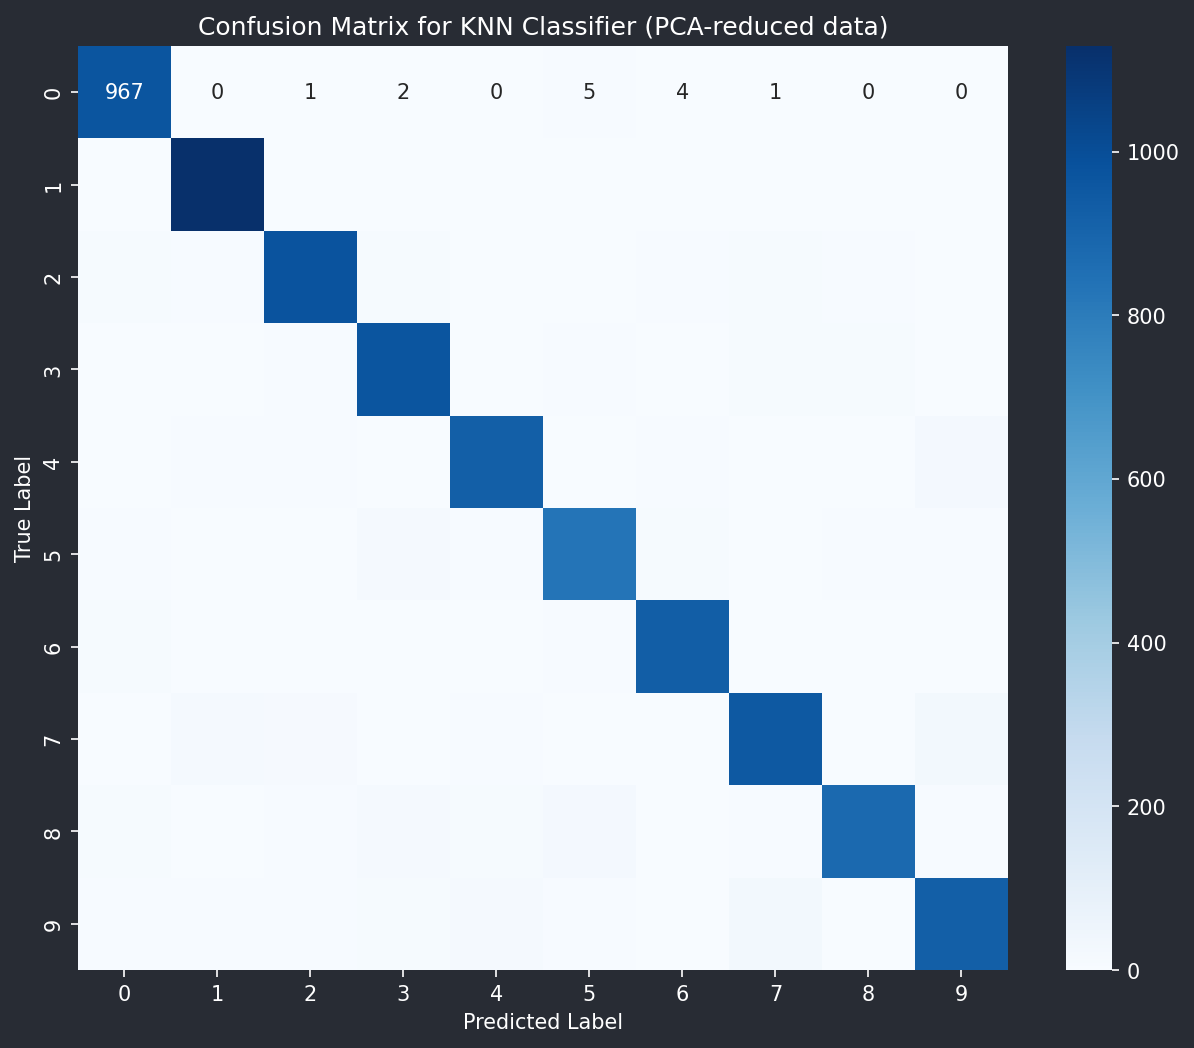

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix for KNN Classifier (PCA-reduced data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


‎ 

<div style="background-color: #505052ff; color: #ffffff; padding: 10px; width: 95%; border-radius: 5px;">

To further reduce the dimensionality of the feature vector, we can choose two methods to reduce the PCA components: 

1. Method 1: Crop the Vector

    This method simply truncates the feature vector to a fixed size.

‎ 

2. Method 2: Select a Lower Variance

    This method uses the variance threshold to select the number of components that capture a lower percentage of variance, thus reducing the dimensionality further.

</div>

‎ 